<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/five_fold_tomatodataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted!")

!pip install albumentations timm -q
print("Done!")

Mounted at /content/drive
Done!


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")

PyTorch : 2.11.0+cu128
GPU     : True
Device  : cuda


In [6]:
TOMATODATASET = '/content/drive/MyDrive/project/data/TomatoDataset'
RESULTS      = '/content/drive/MyDrive/project2/results/fivefold'
MODELS       = '/content/drive/MyDrive/project2/models/fivefold'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

SELECTED_CLASSES = [
    'Tomato_healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato__Tomato_YellowLeaf_Curl_Virus'
]

CONFIG = {
    'image_size'  : 224,
    'batch_size'  : 32,
    'num_workers' : 2,
    'epochs'      : 10,
    'lr'          : 1e-4,
    'seed'        : 42,
    'num_classes' : 5,
    'n_folds'     : 5,
    'mean'        : [0.485, 0.456, 0.406],
    'std'         : [0.229, 0.224, 0.225],
}

short_names  = ['Healthy', 'Bacterial Spot', 'Early Blight',
                'Late Blight', 'Yellow Leaf Curl']
class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])

print("Config ready.")

Config ready.


In [7]:
class_image_paths = {}
for cls in SELECTED_CLASSES:
    cls_path = os.path.join(TOMATODATASET, cls)
    imgs = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    class_image_paths[cls] = imgs

min_count = min(len(p) for p in class_image_paths.values())
print(f"Undersampling all classes to: {min_count}")

all_paths, all_labels = [], []
for cls in SELECTED_CLASSES:
    sampled = random.sample(class_image_paths[cls], min_count)
    all_paths.extend(sampled)
    all_labels.extend([class_to_idx[cls]] * min_count)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total images: {len(all_paths)}")
print("Per class:")
for idx, name in enumerate(short_names):
    print(f"  {name}: {(all_labels == idx).sum()}")

Undersampling all classes to: 2036
Total images: 10180
Per class:
  Healthy: 2036
  Bacterial Spot: 2036
  Early Blight: 2036
  Late Blight: 2036
  Yellow Leaf Curl: 2036


In [8]:
train_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
    ),
    A.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.2, hue=0.1, p=0.5),
    A.RandomShadow(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=20,
                    max_width=20, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

print("Transforms ready.")

Transforms ready.


/tmp/ipykernel_985/2859898537.py:13: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20,
/tmp/ipykernel_985/2859898537.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


In [9]:
class TomatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = np.array(Image.open(self.paths[idx]).convert('RGB'))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

print("TomatoDataset class ready.")

TomatoDataset class ready.


In [10]:
class MultiScaleStem(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch_3x3 = nn.Sequential(
            nn.Conv2d(3, 21, 3, padding=1, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_5x5 = nn.Sequential(
            nn.Conv2d(3, 21, 5, padding=2, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_7x7 = nn.Sequential(
            nn.Conv2d(3, 22, 7, padding=3, bias=False),
            nn.BatchNorm2d(22), nn.ReLU()
        )
        self.compress = nn.Sequential(
            nn.Conv2d(64, 64, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU()
        )

    def forward(self, x):
        return self.compress(torch.cat([
            self.branch_3x3(x),
            self.branch_5x5(x),
            self.branch_7x7(x)
        ], dim=1))


class SEModule(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.se(x).view(x.size(0), x.size(1), 1, 1)


class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, use_se=False):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride,
                      padding=1, groups=in_ch, bias=False),
            nn.GroupNorm(min(32, in_ch), in_ch), nn.ReLU()
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.GroupNorm(min(32, out_ch), out_ch), nn.ReLU()
        )
        self.se      = SEModule(out_ch) if use_se else nn.Identity()
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        return self.dropout(self.se(self.pw(self.dw(x))))


class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = MultiScaleStem()
        self.block1 = DepthwiseSeparableBlock(64,  128, use_se=False)
        self.block2 = DepthwiseSeparableBlock(128, 256, use_se=True)
        self.block3 = DepthwiseSeparableBlock(256, 512, use_se=False)
        self.gem_p  = nn.Parameter(torch.ones(1) * 3.0)
        self.flat   = nn.Flatten()

    def gem_pool(self, x):
        return x.clamp(min=1e-6).pow(self.gem_p).mean(dim=[2,3]).pow(1.0/self.gem_p)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.flat(self.gem_pool(x))


class CAFormerBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.caformer = timm.create_model(
            'caformer_s18', pretrained=True, num_classes=0
        )
        for param in self.caformer.parameters():
            param.requires_grad = False
        for param in self.caformer.stages[3].parameters():
            param.requires_grad = True
        stage3_blocks = list(self.caformer.stages[2].blocks)
        for block in stage3_blocks[-2:]:
            for param in block.parameters():
                param.requires_grad = True
        if hasattr(self.caformer, 'head'):
            for param in self.caformer.head.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.caformer(x)


class CBSEF(nn.Module):
    def __init__(self, feature_dim=1024, reduction=16):
        super().__init__()
        self.se_gate = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(feature_dim // reduction, feature_dim, bias=False),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, trans_feat):
        combined = torch.cat([cnn_feat, trans_feat], dim=1)
        gate     = self.se_gate(combined)
        return combined * gate + combined


class FullHybridModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.cnn_branch   = CNNBranch()
        self.trans_branch = CAFormerBranch()
        self.fusion       = CBSEF(feature_dim=1024, reduction=16)
        self.classifier   = nn.Sequential(
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, CONFIG['num_classes'])
        )

    def forward(self, x):
        cnn_feat   = self.cnn_branch(x)
        trans_feat = self.trans_branch(x)
        fused      = self.fusion(cnn_feat, trans_feat)
        return self.classifier(fused)

print("Model architecture defined.")

Model architecture defined.


In [12]:
import timm
# Pre-download CAFormer weights once before the fold loop
print("Pre-downloading CAFormer weights...")
temp_model = timm.create_model('caformer_s18', pretrained=True, num_classes=0)
del temp_model
import torch
torch.cuda.empty_cache()
print("Done! Now run the 5-fold cell.")

Pre-downloading CAFormer weights...


Done! Now run the 5-fold cell.


In [13]:
skf = StratifiedKFold(n_splits=CONFIG['n_folds'],
                      shuffle=True,
                      random_state=CONFIG['seed'])

fold_results = []

print(f"Starting {CONFIG['n_folds']}-Fold Cross Validation")
print(f"Epochs per fold : {CONFIG['epochs']}")
print("=" * 65)

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n{'='*65}")
    print(f"FOLD {fold+1}/{CONFIG['n_folds']}")
    print(f"{'='*65}")

    # Split data for this fold
    fold_train_paths  = all_paths[train_idx]
    fold_train_labels = all_labels[train_idx]
    fold_val_paths    = all_paths[val_idx]
    fold_val_labels   = all_labels[val_idx]

    print(f"Train: {len(fold_train_paths)} | Val: {len(fold_val_paths)}")

    # Datasets
    fold_train_dataset = TomatoDataset(fold_train_paths,
                                       fold_train_labels, train_transform)
    fold_val_dataset   = TomatoDataset(fold_val_paths,
                                       fold_val_labels,   val_transform)

    # Weighted sampler
    fold_class_counts  = Counter(fold_train_labels.tolist())
    fold_weights       = {c: 1.0/n for c, n in fold_class_counts.items()}
    fold_sample_w      = torch.tensor(
        [fold_weights[l] for l in fold_train_labels], dtype=torch.float
    )
    fold_sampler = WeightedRandomSampler(
        fold_sample_w, len(fold_sample_w), replacement=True
    )

    fold_train_loader = DataLoader(fold_train_dataset,
                                   batch_size=CONFIG['batch_size'],
                                   sampler=fold_sampler,
                                   num_workers=CONFIG['num_workers'],
                                   pin_memory=True)
    fold_val_loader   = DataLoader(fold_val_dataset,
                                   batch_size=CONFIG['batch_size'],
                                   shuffle=False,
                                   num_workers=CONFIG['num_workers'],
                                   pin_memory=True)

    # Fresh model for each fold
    model = FullHybridModel(num_classes=CONFIG['num_classes']).to(device)

    # Optimizer
    optimizer = optim.Adam([
        {'params': model.cnn_branch.parameters(),   'lr': CONFIG['lr']},
        {'params': model.fusion.parameters(),        'lr': CONFIG['lr']},
        {'params': model.classifier.parameters(),    'lr': CONFIG['lr']},
        {'params': filter(lambda p: p.requires_grad,
                   model.trans_branch.parameters()), 'lr': CONFIG['lr'] * 0.1},
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
    )

    # Loss
    fold_counts  = [fold_class_counts.get(i, 1) for i in range(CONFIG['num_classes'])]
    fold_w       = torch.tensor([1.0/c for c in fold_counts],
                                 dtype=torch.float).to(device)
    criterion    = nn.CrossEntropyLoss(weight=fold_w)

    best_fold_acc = 0.0

    for epoch in range(CONFIG['epochs']):
        # Train
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for images, labels in fold_train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)

        train_acc  = correct / total * 100
        avg_loss   = running_loss / len(fold_train_loader)

        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in fold_val_loader:
                images, labels = images.to(device), labels.to(device)
                preds   = model(images).argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)

        val_acc = correct / total * 100
        scheduler.step()

        if val_acc > best_fold_acc:
            best_fold_acc = val_acc
            torch.save(model.state_dict(),
                       os.path.join(MODELS, f'fold_{fold+1}_best.pth'))

        print(f"  Epoch {epoch+1:02d}/{CONFIG['epochs']} | "
              f"Loss: {avg_loss:.4f} | "
              f"Train: {train_acc:.2f}% | "
              f"Val: {val_acc:.2f}% | "
              f"Best: {best_fold_acc:.2f}%")

    fold_results.append(best_fold_acc)
    print(f"\nFold {fold+1} Best Val Acc: {best_fold_acc:.2f}%")

print(f"\n{'='*65}")
print("5-FOLD CROSS VALIDATION COMPLETE")
print(f"{'='*65}")
for i, acc in enumerate(fold_results):
    print(f"  Fold {i+1}: {acc:.2f}%")
print(f"\n  Mean Accuracy : {np.mean(fold_results):.2f}%")
print(f"  Std Deviation : {np.std(fold_results):.2f}%")

Starting 5-Fold Cross Validation
Epochs per fold : 10

FOLD 1/5
Train: 8144 | Val: 2036


  Epoch 01/10 | Loss: 1.0316 | Train: 59.17% | Val: 84.97% | Best: 84.97%
  Epoch 02/10 | Loss: 0.6350 | Train: 77.06% | Val: 92.04% | Best: 92.04%
  Epoch 03/10 | Loss: 0.4876 | Train: 82.45% | Val: 94.40% | Best: 94.40%
  Epoch 04/10 | Loss: 0.4177 | Train: 85.14% | Val: 94.70% | Best: 94.70%
  Epoch 05/10 | Loss: 0.3753 | Train: 86.37% | Val: 95.53% | Best: 95.53%
  Epoch 06/10 | Loss: 0.3505 | Train: 87.21% | Val: 96.46% | Best: 96.46%
  Epoch 07/10 | Loss: 0.3346 | Train: 88.02% | Val: 96.66% | Best: 96.66%
  Epoch 08/10 | Loss: 0.3351 | Train: 88.26% | Val: 97.15% | Best: 97.15%
  Epoch 09/10 | Loss: 0.3264 | Train: 87.72% | Val: 97.00% | Best: 97.15%
  Epoch 10/10 | Loss: 0.3199 | Train: 88.62% | Val: 97.25% | Best: 97.25%

Fold 1 Best Val Acc: 97.25%

FOLD 2/5
Train: 8144 | Val: 2036


  Epoch 01/10 | Loss: 1.0298 | Train: 59.72% | Val: 87.48% | Best: 87.48%
  Epoch 02/10 | Loss: 0.6147 | Train: 77.39% | Val: 91.80% | Best: 91.80%
  Epoch 03/10 | Loss: 0.4860 | Train: 81.93% | Val: 94.89% | Best: 94.89%
  Epoch 04/10 | Loss: 0.4084 | Train: 85.24% | Val: 96.17% | Best: 96.17%
  Epoch 05/10 | Loss: 0.3799 | Train: 86.08% | Val: 96.46% | Best: 96.46%
  Epoch 06/10 | Loss: 0.3512 | Train: 87.16% | Val: 96.71% | Best: 96.71%
  Epoch 07/10 | Loss: 0.3305 | Train: 87.89% | Val: 96.81% | Best: 96.81%
  Epoch 08/10 | Loss: 0.3174 | Train: 88.58% | Val: 97.00% | Best: 97.00%
  Epoch 09/10 | Loss: 0.3106 | Train: 88.61% | Val: 97.05% | Best: 97.05%
  Epoch 10/10 | Loss: 0.3099 | Train: 88.80% | Val: 97.15% | Best: 97.15%

Fold 2 Best Val Acc: 97.15%

FOLD 3/5
Train: 8144 | Val: 2036


  Epoch 01/10 | Loss: 1.0577 | Train: 58.39% | Val: 86.54% | Best: 86.54%
  Epoch 02/10 | Loss: 0.6305 | Train: 77.47% | Val: 91.85% | Best: 91.85%
  Epoch 03/10 | Loss: 0.4970 | Train: 81.74% | Val: 94.35% | Best: 94.35%
  Epoch 04/10 | Loss: 0.4162 | Train: 85.09% | Val: 94.99% | Best: 94.99%
  Epoch 05/10 | Loss: 0.3739 | Train: 86.60% | Val: 95.87% | Best: 95.87%
  Epoch 06/10 | Loss: 0.3434 | Train: 87.44% | Val: 96.37% | Best: 96.37%
  Epoch 07/10 | Loss: 0.3285 | Train: 87.93% | Val: 96.46% | Best: 96.46%
  Epoch 08/10 | Loss: 0.3266 | Train: 88.14% | Val: 96.76% | Best: 96.76%
  Epoch 09/10 | Loss: 0.3281 | Train: 88.11% | Val: 97.10% | Best: 97.10%
  Epoch 10/10 | Loss: 0.3215 | Train: 88.16% | Val: 97.30% | Best: 97.30%

Fold 3 Best Val Acc: 97.30%

FOLD 4/5
Train: 8144 | Val: 2036


  Epoch 01/10 | Loss: 1.0322 | Train: 59.88% | Val: 86.00% | Best: 86.00%
  Epoch 02/10 | Loss: 0.6150 | Train: 77.93% | Val: 93.22% | Best: 93.22%
  Epoch 03/10 | Loss: 0.4906 | Train: 82.29% | Val: 95.43% | Best: 95.43%
  Epoch 04/10 | Loss: 0.4210 | Train: 84.64% | Val: 95.83% | Best: 95.83%
  Epoch 05/10 | Loss: 0.3801 | Train: 86.20% | Val: 96.66% | Best: 96.66%
  Epoch 06/10 | Loss: 0.3576 | Train: 86.64% | Val: 96.91% | Best: 96.91%
  Epoch 07/10 | Loss: 0.3415 | Train: 87.84% | Val: 97.25% | Best: 97.25%
  Epoch 08/10 | Loss: 0.3356 | Train: 87.64% | Val: 97.40% | Best: 97.40%
  Epoch 09/10 | Loss: 0.3220 | Train: 88.33% | Val: 97.50% | Best: 97.50%
  Epoch 10/10 | Loss: 0.3258 | Train: 87.95% | Val: 97.40% | Best: 97.50%

Fold 4 Best Val Acc: 97.50%

FOLD 5/5
Train: 8144 | Val: 2036


  Epoch 01/10 | Loss: 1.0184 | Train: 60.62% | Val: 85.90% | Best: 85.90%
  Epoch 02/10 | Loss: 0.6320 | Train: 77.28% | Val: 91.40% | Best: 91.40%
  Epoch 03/10 | Loss: 0.4879 | Train: 82.02% | Val: 93.76% | Best: 93.76%
  Epoch 04/10 | Loss: 0.4167 | Train: 84.98% | Val: 94.84% | Best: 94.84%
  Epoch 05/10 | Loss: 0.3647 | Train: 87.02% | Val: 95.83% | Best: 95.83%
  Epoch 06/10 | Loss: 0.3512 | Train: 87.41% | Val: 96.56% | Best: 96.56%
  Epoch 07/10 | Loss: 0.3262 | Train: 88.33% | Val: 96.95% | Best: 96.95%
  Epoch 08/10 | Loss: 0.3284 | Train: 88.20% | Val: 96.81% | Best: 96.95%
  Epoch 09/10 | Loss: 0.3114 | Train: 88.91% | Val: 97.10% | Best: 97.10%
  Epoch 10/10 | Loss: 0.3191 | Train: 88.41% | Val: 97.15% | Best: 97.15%

Fold 5 Best Val Acc: 97.15%

5-FOLD CROSS VALIDATION COMPLETE
  Fold 1: 97.25%
  Fold 2: 97.15%
  Fold 3: 97.30%
  Fold 4: 97.50%
  Fold 5: 97.15%

  Mean Accuracy : 97.27%
  Std Deviation : 0.13%


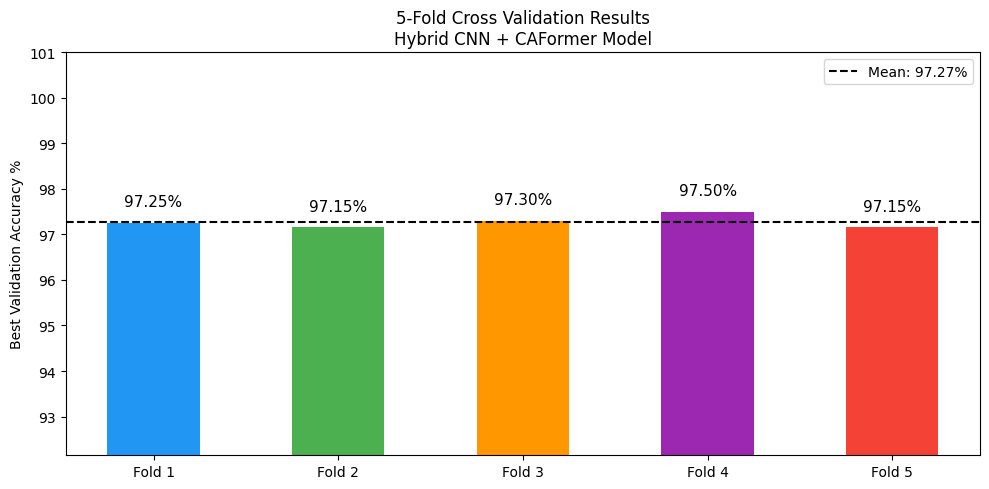

Mean : 97.27%
Std  : 0.13%


In [14]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    [f'Fold {i+1}' for i in range(CONFIG['n_folds'])],
    fold_results,
    color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'],
    width=0.5
)

# Add value labels on bars
for bar, acc in zip(bars, fold_results):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11)

plt.axhline(y=np.mean(fold_results), color='black',
            linestyle='--', label=f'Mean: {np.mean(fold_results):.2f}%')
plt.title('5-Fold Cross Validation Results\nHybrid CNN + CAFormer Model')
plt.ylabel('Best Validation Accuracy %')
plt.ylim(min(fold_results) - 5, 101)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'fivefold_results.png'), dpi=150)
plt.show()

print(f"Mean : {np.mean(fold_results):.2f}%")
print(f"Std  : {np.std(fold_results):.2f}%")